In [ ]:
import cv2
from cv2 import imwrite

input_file="C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing video/alligator/image_processing8_alligator.mp4"

vid=cv2.VideoCapture(input_file)
x=0
if not vid.isOpened():
        print("error")
else:
      while True:
   
        rec,frame= vid.read()

        if not rec:
            print("video frame can't process")
            break
        if
        cv2.imshow("frame",frame)
        imwrite(f"C:\Users\user\Documents\RUSL\2nd Year\ICT2403-Graphics and Image Processing\Lab\image processing project\image processing video\alligator\extracted/frame_{x}.png",frame)
            
        x+=1
        if cv2.waitKey(40) == ord('q'):
            break

vid.release()
cv2.destroyAllWindows()

    


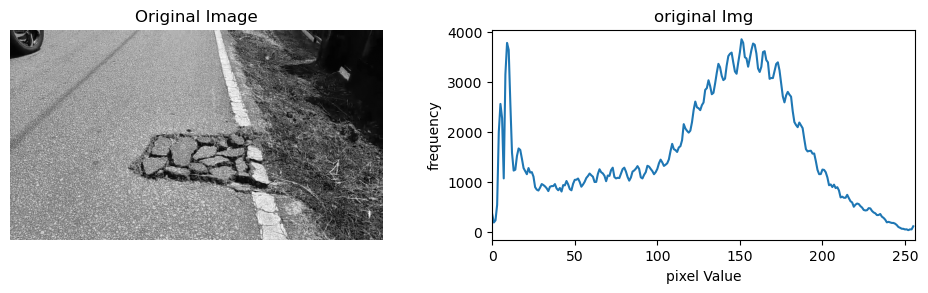

[[ 33  31  34 ...  10  10  10]
 [ 31  32  33 ...  10  10  10]
 [ 30  32  32 ...  10  10  10]
 ...
 [148 138 145 ... 125  89  94]
 [158 165 157 ...  97  69  68]
 [156 155 130 ...  96  77  76]]


In [8]:
import cv2,numpy as np,matplotlib.pyplot as plt

image_path="11.jpg"
img=cv2.imread(image_path,0)

def plot_histrogram(img,title):
       histrogram= cv2.calcHist([img], [0], None, [256],[0, 256])
       
       plt.title(title)
       plt.xlabel("pixel Value")
       plt.ylabel("frequency")
       plt.plot(histrogram)
       plt.xlim([0,256])
       plt.show()

if img is None:
    print("Cant Process video")
else:
  plt.figure(figsize=(12,6))

  plt.subplot(2, 2, 1)
  plt.imshow(img, cmap='gray')
  plt.title("Original Image")
  plt.axis('off')
  plt.subplot(2,2, 2)
  plot_histrogram(img,"original Img")
print(img)

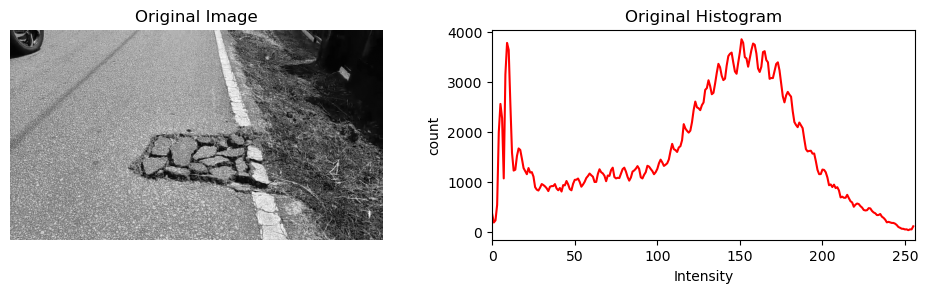

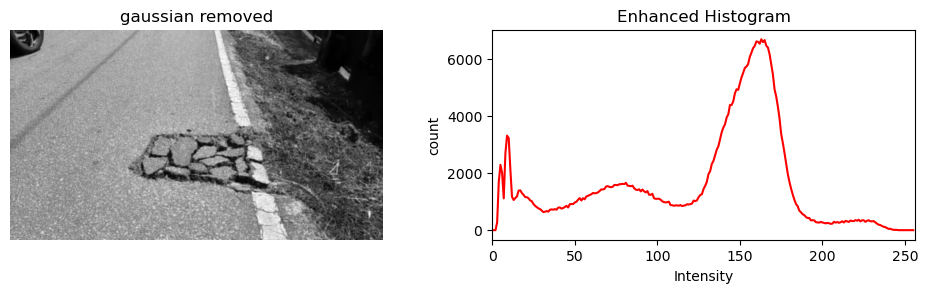

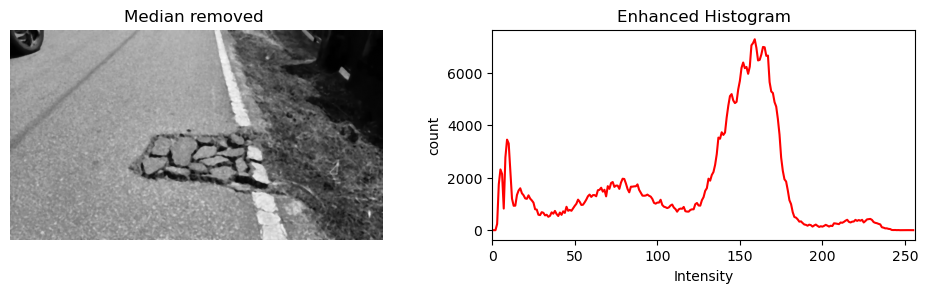

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def histogram(image,title):
    histogram = cv2.calcHist([image],[0],None,[256],[0,256])

    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("count")
    plt.plot(histogram,color="red")
    plt.xlim([0,256])
    #plt.bar(range(256), histogram[:,0], width=1)

path = "C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/alligator/extracted/11.jpg"
img = cv2.imread(path,0)

plt.figure(figsize =(12,6))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
histogram(img,"Original Histogram")


""" denoise """
gaussian = cv2.GaussianBlur(img, (5,5), 1.0)

plt.figure(figsize =(12,6))

plt.subplot(2, 2, 1)
plt.imshow(gaussian, cmap='gray')
plt.title("gaussian removed")
plt.axis('off')

plt.subplot(2,2,2)
histogram(gaussian,"Enhanced Histogram")


""" denoise """
median_img=cv2.medianBlur(img,5)
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(median_img,cmap="gray")
plt.title("Median removed ")
plt.axis("off")

plt.subplot(2,2,2)
histogram(median_img,"Enhanced Histogram")

In [1]:
import cv2
from cv2 import imwrite

source="C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/alligator/extracted/"
gray_path="C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/alligator/GRAY/"
gaussian_path="C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/alligator/Guassian/"
median_path="C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/alligator/Median/"

for i in range(1, 15):
   file_name=f"{i}.jpg"
   full_path= source + file_name
   img=cv2.imread(full_path,0)
   if img is None:
       print("cannot read frames")
       continue
   else:    
       gsave_path=gray_path+f"gray_{i}.png" 
       imwrite(gsave_path,img)

       gaussian_img= cv2.GaussianBlur(img, (5, 5), 1.0)
       saveGausian=gaussian_path+ f"Gaussian_{i}.png"
       
    
       median_img=cv2.medianBlur(img, 5)
       saveMEdian= median_path + f"Median_{i}.png"
    
       imwrite(saveGausian,gaussian_img)
       imwrite(saveMEdian,median_img)

In [2]:
import cv2
import numpy as np
import math


base_path_gray = "C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/alligator/GRAY/gray_"
base_path_gaussian = "C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/alligator/Guassian/Gaussian_"
base_path_median = "C:/Users/user/Documents/RUSL/2nd Year/ICT2403-Graphics and Image Processing/Lab/image processing project/image processing video/alligator/Median/Median_"

total_psnr_gaussian = 0
total_psnr_median = 0
successful_frames = 0

def calculate_psnr_manual(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * math.log10((max_pixel ** 2) / mse)
    return psnr

print("Starting batch PSNR calculation...")

for i in range(1, 31):
    gray_file = f"{base_path_gray}{i}.png"
    gaussian_file = f"{base_path_gaussian}{i}.png"
    median_file = f"{base_path_median}{i}.png"

    original = cv2.imread(gray_file, 0)
    filtered_g = cv2.imread(gaussian_file, 0)
    filtered_m = cv2.imread(median_file, 0)

    if original is not None and filtered_g is not None and filtered_m is not None:
        psnr_g = calculate_psnr_manual(original, filtered_g)
        psnr_m = calculate_psnr_manual(original, filtered_m)
        
        total_psnr_gaussian += psnr_g
        total_psnr_median += psnr_m
        successful_frames += 1
        
        print(f"Frame {i}: Gaussian = {psnr_g:.2f} dB, Median = {psnr_m:.2f} dB")
    else:
        print(f"Warning: Could not load frame {i}. Skipping...")

if successful_frames > 0:
    avg_psnr_gaussian = total_psnr_gaussian / successful_frames
    avg_psnr_median = total_psnr_median / successful_frames
    
    print("\n" + "="*40)
    print(f"FINAL RESULTS (Averaged over {successful_frames} frames)")
    print("="*40)
    print(f"Average Gaussian PSNR: {avg_psnr_gaussian:.2f} dB")
    print(f"Average Median PSNR:   {avg_psnr_median:.2f} dB")
    print("="*40)
else:
    print("Error: No frames were successfully processed.")

Starting batch PSNR calculation...
Frame 1: Gaussian = 22.73 dB, Median = 19.69 dB
Frame 2: Gaussian = 22.18 dB, Median = 19.41 dB
Frame 3: Gaussian = 22.70 dB, Median = 19.75 dB
Frame 4: Gaussian = 22.23 dB, Median = 19.54 dB
Frame 5: Gaussian = 22.81 dB, Median = 19.98 dB
Frame 6: Gaussian = 23.09 dB, Median = 20.24 dB
Frame 7: Gaussian = 22.45 dB, Median = 19.93 dB
Frame 8: Gaussian = 22.75 dB, Median = 20.14 dB
Frame 9: Gaussian = 22.41 dB, Median = 19.95 dB
Frame 10: Gaussian = 22.58 dB, Median = 20.09 dB
Frame 11: Gaussian = 23.21 dB, Median = 20.53 dB
Frame 12: Gaussian = 23.05 dB, Median = 20.46 dB
Frame 13: Gaussian = 22.53 dB, Median = 20.17 dB
Frame 14: Gaussian = 23.07 dB, Median = 20.50 dB

FINAL RESULTS (Averaged over 14 frames)
Average Gaussian PSNR: 22.70 dB
Average Median PSNR:   20.03 dB
